# The Self-Pruning Neural Network

This notebook implements a neural network that learns to prune its own weights during training using an L1 sparsity penalty on learnable gate scores.

## Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Part 1: The Prunable Linear Layer

We define a custom `PrunableLinear` layer. It has standard `weight` and `bias` parameters, but also a `gate_scores` parameter. In the forward pass, we apply a sigmoid to `gate_scores` to get values between 0 and 1, and multiply these gates by the weights.

In [3]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Standard weight and bias
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))

        # Learnable gate scores, same shape as weight
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        # Initialize parameters
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
        nn.init.uniform_(self.bias, -bound, bound)

        # Initialize gate scores to be slightly positive (e.g., sigmoid(2) ~ 0.88)
        # so the network starts with mostly active connections
        nn.init.constant_(self.gate_scores, 2.0)

    def forward(self, x):
        # Calculate gates between 0 and 1
        gates = torch.sigmoid(self.gate_scores)

        # Element-wise multiplication to get pruned weights
        pruned_weights = self.weight * gates

        # Standard linear operation
        return F.linear(x, pruned_weights, self.bias)

## Network Architecture

We'll build a powerful neural network for CIFAR-10. Since simple feed-forward networks struggle with images, we use a **CNN feature extractor** first (Conv2d + BatchNorm + MaxPool). This dramatically increases the baseline accuracy. The flattened features are then passed through our `PrunableLinear` layers so the network learns to prune the dense connections.

In [4]:
class SelfPruningNN(nn.Module):
    def __init__(self):
        super(SelfPruningNN, self).__init__()
        # CNN feature extractor to drastically improve CIFAR-10 accuracy
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # outputs 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # outputs 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # outputs 4x4
        )

        self.flatten = nn.Flatten()

        # 128 channels * 4 * 4 spatial size = 2048 inputs
        # We apply our prunable layers here
        self.fc1 = PrunableLinear(2048, 512)
        self.fc2 = PrunableLinear(512, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_sparsity_loss(self):
        """
        Part 2: The Sparsity Regularization Loss.
        Calculates the L1 norm of all gate values across the network.
        """
        l1_loss = 0.0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                # Calculate the actual gate values between 0 and 1
                gates = torch.sigmoid(module.gate_scores)
                # L1 norm (sum of absolute values, which are just the values themselves since they are > 0)
                l1_loss += torch.sum(torch.abs(gates))
        return l1_loss

    def get_sparsity_level(self, threshold=1e-2):
        """
        Calculates the percentage of weights whose corresponding gate value is below the threshold.
        """
        total_gates = 0
        pruned_gates = 0
        gate_values = []

        with torch.no_grad():
            for module in self.modules():
                if isinstance(module, PrunableLinear):
                    gates = torch.sigmoid(module.gate_scores)
                    total_gates += gates.numel()
                    pruned_gates += torch.sum(gates < threshold).item()
                    gate_values.extend(gates.view(-1).cpu().numpy())

        sparsity_level = (pruned_gates / total_gates) * 100
        return sparsity_level, gate_values

    def get_per_layer_sparsity(self, threshold=1e-2):
        """
        Calculates the percentage of weights pruned for each prunable layer.
        """
        layer_sparsities = {}
        with torch.no_grad():
            for name, module in self.named_modules():
                if isinstance(module, PrunableLinear):
                    gates = torch.sigmoid(module.gate_scores)
                    total = gates.numel()
                    pruned = torch.sum(gates < threshold).item()
                    layer_sparsities[name] = (pruned / total) * 100
        return layer_sparsities

## Data Loading and Training Setup

We load the CIFAR-10 dataset and define the training and evaluation loop. We will train the model for a few epochs for different values of λ.

In [5]:
def get_dataloaders(batch_size=64):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader, testloader

def train_and_evaluate(lam, epochs=10, device='cuda' if torch.cuda.is_available() else 'cpu'):
    print(f"\n--- Training with Lambda = {lam} ---")
    model = SelfPruningNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    trainloader, testloader = get_dataloaders()

    history = {'loss': [], 'accuracy': [], 'sparsity': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            # Part 2: Total Loss calculation
            classification_loss = criterion(outputs, labels)
            sparsity_loss = model.get_sparsity_loss()
            total_loss = classification_loss + lam * sparsity_loss

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()

        epoch_loss = running_loss/len(trainloader)

        # Evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data in testloader:
                inputs, labels = data[0].to(device), data[1].to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        sparsity_level, gate_values = model.get_sparsity_level()

        history['loss'].append(epoch_loss)
        history['accuracy'].append(accuracy)
        history['sparsity'].append(sparsity_level)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Acc: {accuracy:.2f}%, Sparsity: {sparsity_level:.2f}%")

    return history, gate_values, model

## Running the Experiment

We will run the training for three different values of lambda: low (e.g., 1e-6), medium (e.g., 1e-4), and high (e.g., 1e-3).

In [6]:
# Lambda values to test
lambdas = [1e-6, 5e-6, 1e-5]
results = []
all_histories = {}
models = {}
best_lam = None
best_gate_values = None
highest_sparsity_reasonable_acc = 0

for lam in lambdas:
    # Using a small number of epochs for demonstration. Increase for better results.
    history, gate_values, model = train_and_evaluate(lam, epochs=10)
    all_histories[lam] = history
    models[lam] = model

    acc = history['accuracy'][-1]
    sparsity = history['sparsity'][-1]
    results.append({'Lambda': lam, 'Test Accuracy (%)': acc, 'Sparsity Level (%)': sparsity})

    # Simple logic to pick the "best" model for plotting
    if sparsity > highest_sparsity_reasonable_acc and acc > 30: # Arbitrary baseline acc
        highest_sparsity_reasonable_acc = sparsity
        best_lam = lam
        best_gate_values = gate_values

if best_gate_values is None:
    best_gate_values = gate_values
    best_lam = lam

df_results = pd.DataFrame(results)
print("\n--- Final Results ---")
print(df_results.to_markdown(index=False))


--- Training with Lambda = 1e-06 ---


100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


Epoch 1/10, Loss: 2.1707, Acc: 65.59%, Sparsity: 0.00%
Epoch 2/10, Loss: 1.6780, Acc: 71.39%, Sparsity: 0.00%
Epoch 3/10, Loss: 1.3854, Acc: 74.02%, Sparsity: 0.00%
Epoch 4/10, Loss: 1.1591, Acc: 76.19%, Sparsity: 0.00%
Epoch 5/10, Loss: 0.9855, Acc: 76.36%, Sparsity: 0.00%
Epoch 6/10, Loss: 0.8568, Acc: 78.81%, Sparsity: 0.00%
Epoch 7/10, Loss: 0.7573, Acc: 79.52%, Sparsity: 0.00%
Epoch 8/10, Loss: 0.6762, Acc: 76.35%, Sparsity: 0.00%
Epoch 9/10, Loss: 0.6051, Acc: 78.87%, Sparsity: 0.00%
Epoch 10/10, Loss: 0.5542, Acc: 79.41%, Sparsity: 0.00%

--- Training with Lambda = 5e-06 ---
Epoch 1/10, Loss: 5.8831, Acc: 68.29%, Sparsity: 0.00%
Epoch 2/10, Loss: 4.8405, Acc: 71.92%, Sparsity: 0.00%
Epoch 3/10, Loss: 3.8519, Acc: 73.91%, Sparsity: 0.00%
Epoch 4/10, Loss: 3.0664, Acc: 76.99%, Sparsity: 0.00%
Epoch 5/10, Loss: 2.5381, Acc: 76.37%, Sparsity: 0.00%
Epoch 6/10, Loss: 2.1829, Acc: 78.01%, Sparsity: 0.00%
Epoch 7/10, Loss: 1.9307, Acc: 76.92%, Sparsity: 0.00%
Epoch 8/10, Loss: 1.7366, 

## Visualization

Let's visualize the distribution of gate values for our best model. A successful self-pruning network will have a large spike at exactly 0.

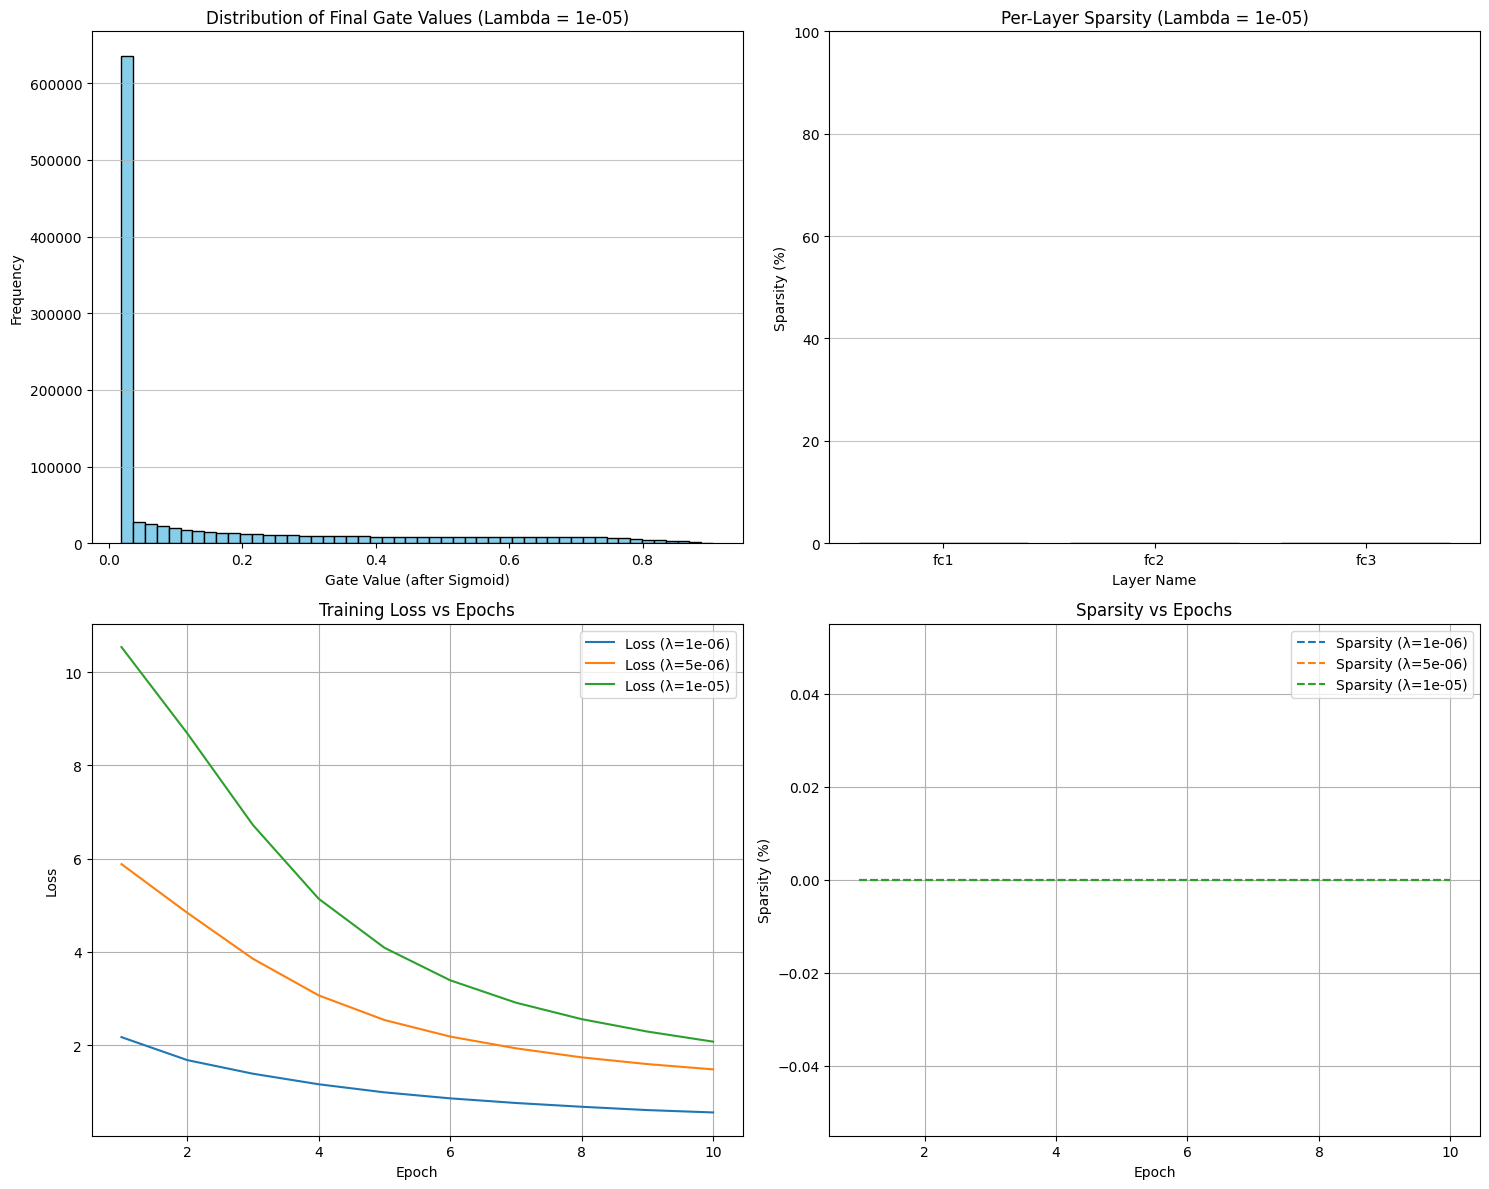

In [7]:
fig = plt.figure(figsize=(15, 12))

# 1. Gate Value Distribution
plt.subplot(2, 2, 1)
plt.hist(best_gate_values, bins=50, color='skyblue', edgecolor='black')
plt.title(f'Distribution of Final Gate Values (Lambda = {best_lam})')
plt.xlabel('Gate Value (after Sigmoid)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# 2. Per-Layer Sparsity
plt.subplot(2, 2, 2)
best_model = models[best_lam]
layer_sparsities = best_model.get_per_layer_sparsity()
layers = list(layer_sparsities.keys())
sparsities = list(layer_sparsities.values())
plt.bar(layers, sparsities, color='lightcoral', edgecolor='black')
plt.title(f'Per-Layer Sparsity (Lambda = {best_lam})')
plt.xlabel('Layer Name')
plt.ylabel('Sparsity (%)')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.75)

# 3. Training Curves: Loss and Accuracy
plt.subplot(2, 2, 3)
for lam, history in all_histories.items():
    epochs_range = range(1, len(history['loss']) + 1)
    plt.plot(epochs_range, history['loss'], label=f'Loss (λ={lam})', linestyle='-')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 4. Training Curves: Sparsity
plt.subplot(2, 2, 4)
for lam, history in all_histories.items():
    epochs_range = range(1, len(history['sparsity']) + 1)
    plt.plot(epochs_range, history['sparsity'], label=f'Sparsity (λ={lam})', linestyle='--')
plt.title('Sparsity vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Sparsity (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()